<h4>Assessment 2 - Brief</h4>

* Analytic question formulation
* Data wrangling
* Data preparation and sampling
* Descriptive statistics
* Inferential statistics (Confidence interval)
* Inferential statistics (Two-sample t-Test)

<h4><strong>Question for analysis</strong></h4>
Do goalkeepers with higher aggression (more actions outside the penalty area) have significantly different save efficiency compared to less aggressive goalkeepers? Nb. only goalkeeper that played in FIFA world cup 2026.

<h5>Thought's question - Are aggressive keepers:</h5>

1. more efficient shot‑stoppers ?
2. or less efficient ?
3. or no different at all ?

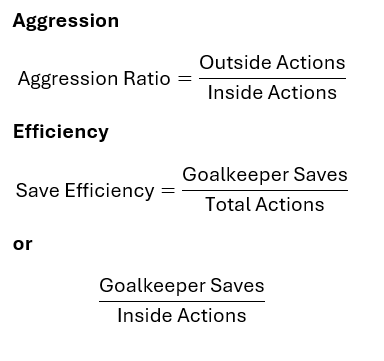

Note: 
- We are to work with sample data calculate t sample stats (sample size to be min 30-40 players)
- the sample size of goalkeeper.csv = 61 goalkeepers 

1. Assign each player an id
3. Calculate confidence interval - CI - Inferential stat
4. What confidence level - we are using 95%
5. Create a sample T test - Compaire to previous years 2022 world cup - goalkeeper statistics
6. Hypothsis testing - Inferential stat (two-sample T test) 2022 sample vs 2026 sample - goalkeeper statistics
8. Create powerpoint of analysis of Goalkeeper process to answer question
9. Create video for youtube of analysis. Then upload to github repository - name: HIT140_Assessment-2_Group23 - https://github.com/DanDooLoo/HIT140_Assessment-2_Group23

<h4>Sample for point 1.:</h4>

Assign each player an id. 

The code I will use is:
- gk["Player_ID"] = gk.index + 1

<h4>Sample for point 2.:</h4>

To create a sample from goalkepper 2026 and 2022 FIFA World Cup - Sample to randomly select 30 rows from dataset size of 61 rows

The code I will use is:
code is: 
- sample_gk_t_test_2026 = goalkeeper.sample(n=30, random_state=42)

Note: random_state=42 is a seed for the random number generator

In [111]:
# import required packages for stat analysis
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.stats.weightstats as stm
import math
import matplotlib.pyplot as plt

# read in data collected from FIFA Official website
gk = pd.read_csv("goalkeeper.csv")
gk["Player_ID"] = gk.index + 1


In [112]:
gk.head()

,Rank,Player,Team,Position,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,Player_ID
0,1,Orlando Gill,PAR,GK,28,141,124,1
1,2,Eloy Room,CUW,GK,21,81,72,2
2,3,Emiliano Martinez,ARG,GK,20,111,97,3
3,3,Gregor Kobel,SUI,GK,20,100,88,4
4,3,Diogo Costa,POR,GK,20,114,93,5


<strong><h3>Analysis: Step 1 - Seperate goalkeepers into high and low aggression groups</h3></strong>
1. High aggression group → above median aggression ratio
2. Low aggression group → below median aggression ratio


In [113]:
# Step 1: --
# group goalkeepers into high and low aggression --
# create variables --
gk["Aggression_Ratio"] = gk["Goalkeeper_Actions_outside_PenaltyArea"] / gk["Goalkeeper_Actions_inside_PenaltyArea"]
gk["Save_Efficienty"] = gk["Goalkeeper_Saves"] / (gk["Goalkeeper_Actions_inside_PenaltyArea"] + gk["Goalkeeper_Actions_outside_PenaltyArea"])


In [114]:
# Step 2: --
# create medians to be able to sort goalkeepers into high and low group --
median_agress = gk["Aggression_Ratio"].median()

In [115]:
# Step 3: --
# create high and low grouping of goalkeepers
high_agress = gk[gk["Aggression_Ratio"] > median_agress]
low_agress = gk[gk["Aggression_Ratio"] <= median_agress]

In [116]:
# Review check point 1: --
# check if it actually worked
print("High aggression group size: ", len(high_agress))
print("Low aggression group size: ", len(low_agress))

High aggression group size:  30
Low aggression group size:  31


In [117]:
# Review check point 2: --
# check if it actually worked - display header rows
high_agress[["Player", "Team", "Aggression_Ratio", "Save_Efficienty"]].head()


,Player,Team,Aggression_Ratio,Save_Efficienty
0,Orlando Gill,PAR,0.879433,0.105660
1,Eloy Room,CUW,0.888889,0.137255
2,Emiliano Martinez,ARG,0.873874,0.096154
3,Gregor Kobel,SUI,0.880000,0.106383
9,Mohammed Alowais,KSA,0.906977,0.103659


In [118]:
# Review check point 3: --
# check if it actually worked - display header rows
low_agress[["Player", "Team", "Aggression_Ratio", "Save_Efficienty"]].head()

,Player,Team,Aggression_Ratio,Save_Efficienty
4,Diogo Costa,POR,0.815789,0.096618
5,Jordan Pickford,ENG,0.827068,0.078189
6,Yassine Bounou,MAR,0.812500,0.093596
7,Vozinha,CPV,0.750000,0.075630
8,Zion Suzuki,JPN,0.820513,0.119718


<strong><h3>Analysis: Step 2 - Create descriptive stats for high and low aggression groups</h3></strong>

I will now calculate the following descriptive statistics for goalkeeper high and low aggression

- mean
- median
- standard deviation
- sample size (n)

In [119]:
# Descriptive stats - mean, median, std dev for high aggression goalkeepers
high_mean = high_agress["Save_Efficienty"].mean()
high_median = high_agress["Save_Efficienty"].median()
high_std = high_agress["Save_Efficienty"].std()
high_n = len(high_agress)

In [120]:
# Descriptive stats - mean, median, std dev for low aggression goalkeepers
low_mean = low_agress["Save_Efficienty"].mean()
low_median = low_agress["Save_Efficienty"].median()
low_std = low_agress["Save_Efficienty"].std()
low_n = len(low_agress)

<strong><h4>Analysis: Step 3 - Compute confidence intervals (CI)</h4><strong>

I will be using a 95% CI for the goalkeeper groups - high and low
 
The general formula for a confidence interval around a mean is:
CI = X̄ ± (Z × (s / √n))

Where:

X̄ is the sample mean.

Z is the Z-score corresponding to the confidence level (e.g., 1.96 for 95% confidence).

s is the sample standard deviation.

n is the sample size.

In [121]:
# calculation confidence interval goalkeeper high aggression
ci_low, ci_upp = stm._zconfint_generic(high_mean, high_n / math.sqrt(high_n), alpha=0.05, alternative='two-sided') # 95% confidence interval aplpha=0.05 or 5%
print("CI high aggression goalkeepers: %.2f to %.2f" % (ci_low, ci_upp))
    

CI high aggression goalkeepers: -10.64 to 10.83


In [122]:
# calculation confidence interval goalkeeper low aggression
ci_low, ci_upp = stm._zconfint_generic(low_mean, low_n / math.sqrt(low_n), alpha=0.05, alternative='two-sided') # 95% confidence interval aplpha=0.05 or 5%
print("CI low aggression goalkeepers: %.2f to %.2f" % (ci_low, ci_upp))

CI low aggression goalkeepers: -10.84 to 10.99


In [123]:
# Random sample of 30 goalkeepers - high aggression
sample_30 = high_agress["Save_Efficienty"].sample(30, random_state=42)

# Population mean - high aggression
population_mean = high_agress["Save_Efficienty"].mean()

# One-sample t-test - high aggression
t_stat, p_value = stats.ttest_1samp(sample_30, population_mean)

print("One-sample t-test:")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"Population mean = {population_mean:.4f}")
print(f"Sample mean = {sample_30.mean():.4f}")

One-sample t-test:
  t-statistic = 0.0000
  p-value = 1.0000
Population mean = 0.0903
Sample mean = 0.0903


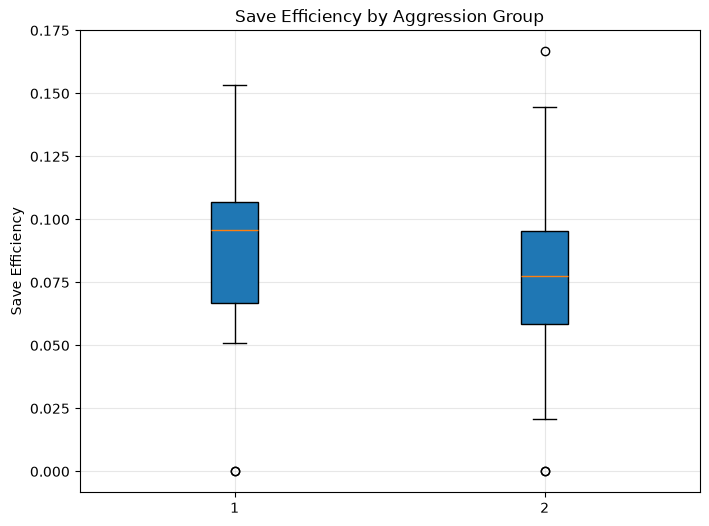

In [124]:
plt.figure(figsize=(8,6))
plt.boxplot(
    [high_agress["Save_Efficienty"], low_agress["Save_Efficienty"]],
    label=["High Aggression", "Low Aggression"],
    patch_artist=True
)

plt.title("Save Efficiency by Aggression Group")
plt.ylabel("Save Efficiency")
plt.grid(alpha=0.3)
plt.show()

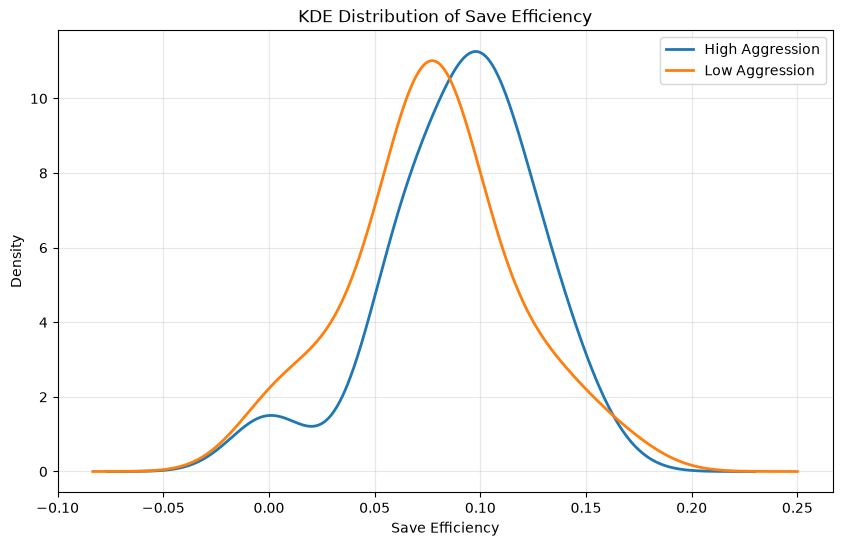

In [125]:
plt.figure(figsize=(10,6))

high_agress["Save_Efficienty"].plot(kind='kde', label='High Aggression', linewidth=2)
low_agress["Save_Efficienty"].plot(kind='kde', label='Low Aggression', linewidth=2)

plt.title("KDE Distribution of Save Efficiency")
plt.xlabel("Save Efficiency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [126]:
# Two-sample t-test (independent samples)
t_stat, p_value = stats.ttest_ind(
    high_agress["Save_Efficienty"],
    low_agress["Save_Efficienty"],
    equal_var=False  # Welch's t-test (safer when variances differ)
)

print("Two-sample t-test (High vs Low Aggression):")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.4f}")

Two-sample t-test (High vs Low Aggression):
  t-statistic = 1.3927
  p-value = 0.1690


Cohen’s d is a measure of effect size. It tells me how big the difference is between two groups, expressed in standard deviation units.
Where a t‑test tells me whether a difference is statistically significant,
Cohen’s d tells me whether the difference is meaningful.

This will tell me how far apart are the two group means, relative to the spread of the data

Interpretation guide:
0.2 = small
0.5 = medium
0.8+ = large

In [127]:
# What does this mean? How big is the difference between the two samples?
mean_high = high_agress["Save_Efficienty"].mean()
mean_low = low_agress["Save_Efficienty"].mean()

std_high = high_agress["Save_Efficienty"].std()
std_low = low_agress["Save_Efficienty"].std()

# Standard deviation
n_high = len(high_agress)
n_low = len(low_agress)

pooled_sd = (((n_high - 1)*std_high**2 + (n_low - 1)*std_low**2) / (n_high + n_low - 2))**0.5

cohens_d = (mean_high - mean_low) / pooled_sd

print(f"Cohen's d = {cohens_d:.4f}")

Cohen's d = 0.3562


<h4>Scatter Plot: Aggression vs Save Efficiency</h4>

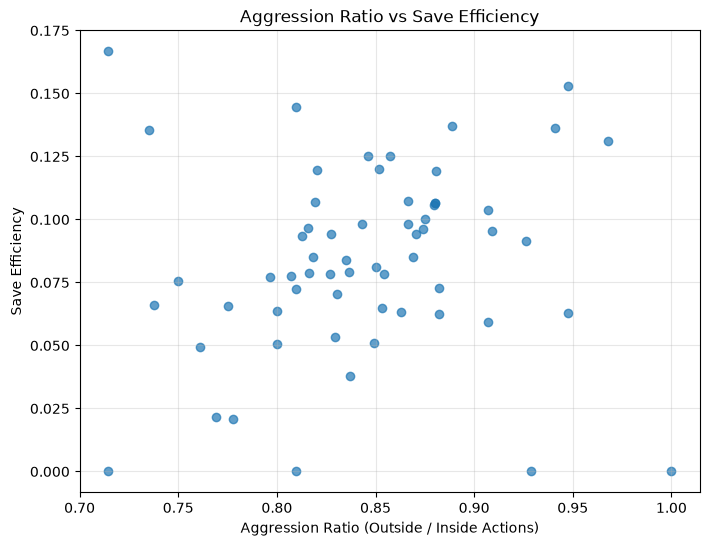

In [128]:
plt.figure(figsize=(8,6))
plt.scatter(gk["Aggression_Ratio"], gk["Save_Efficienty"], alpha=0.7)

plt.title("Aggression Ratio vs Save Efficiency")
plt.xlabel("Aggression Ratio (Outside / Inside Actions)")
plt.ylabel("Save Efficiency")
plt.grid(alpha=0.3)
plt.show()


<h4>Histogram Comparison</h4>

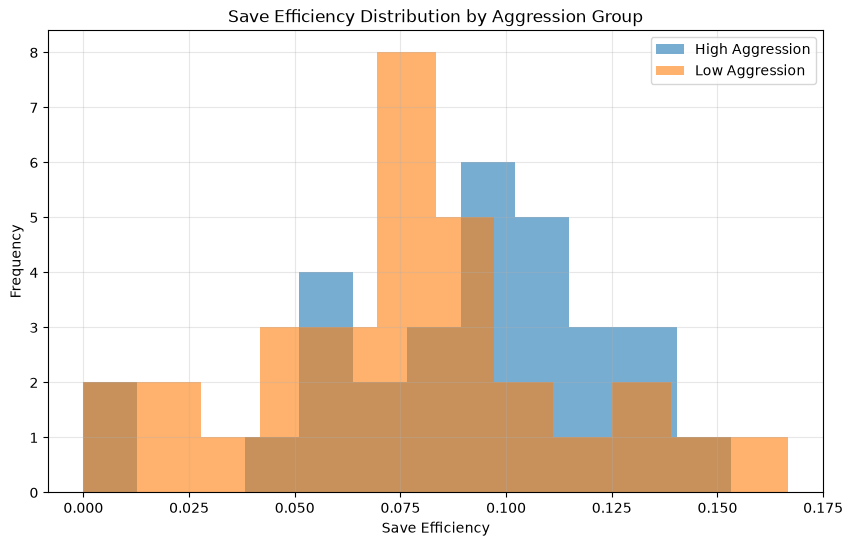

In [129]:
plt.figure(figsize=(10,6))

plt.hist(high_agress["Save_Efficienty"], bins=12, alpha=0.6, label="High Aggression")
plt.hist(low_agress["Save_Efficienty"], bins=12, alpha=0.6, label="Low Aggression")

plt.title("Save Efficiency Distribution by Aggression Group")
plt.xlabel("Save Efficiency")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<h4>Now for the pretty data</h4>

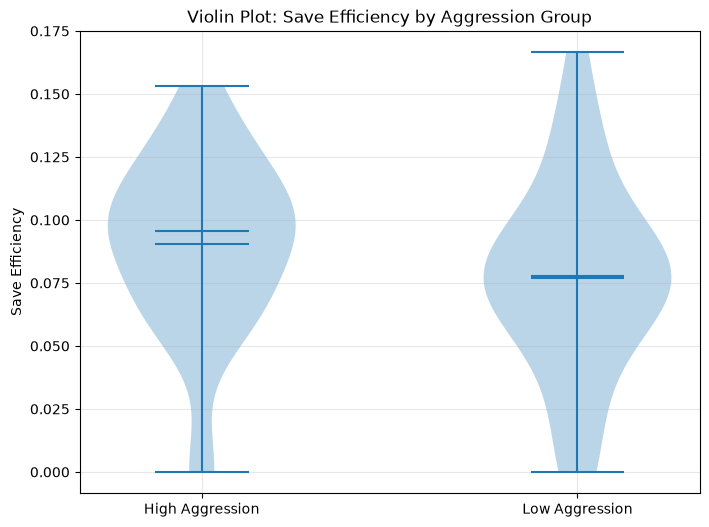

In [130]:
plt.figure(figsize=(8,6))
plt.violinplot(
    [high_agress["Save_Efficienty"], low_agress["Save_Efficienty"]],
    showmeans=True,
    showmedians=True
)

plt.xticks([1, 2], ["High Aggression", "Low Aggression"])
plt.title("Violin Plot: Save Efficiency by Aggression Group")
plt.ylabel("Save Efficiency")
plt.grid(alpha=0.3)
plt.show()
